# Day 6 — PyTorch Training Loop with Validation
Adding validation loop, early stopping, and loss curve analysis to detect overfitting.

In [1]:
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'True'

In [59]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import pandas as pd
from  sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import os,copy
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score

In [3]:
device="cuda" if torch.cuda.is_available() else "cpu"
print(device)

cpu


In [4]:
#  Load & prepare data

In [8]:
df=pd.read_csv("data/titanic_clean.csv")
x=df.drop(['Survived'], axis=1)
y=df['Survived']
scaler =StandardScaler()
x=scaler.fit_transform(x)
x_train, x_test, y_train, y_test=train_test_split(x, y, test_size=.2, random_state=42, stratify=y)
x_train, x_val, y_train, y_val=train_test_split(x_train, y_train, test_size=.2, random_state=42, stratify=y_train)
print(f"Train : {x_train.shape[0]} | {x_val.shape[0]} | {x_test.shape[0]}")
# conver into tenstor
x_train_t=torch.FloatTensor(x_train)
x_val_t=torch.FloatTensor(x_val)
x_test_t=torch.FloatTensor(x_test)
y_train_t=torch.FloatTensor(y_train.values).reshape(-1,1)
y_val_t=torch.FloatTensor(y_val.values).reshape(-1,1)
y_test_t=torch.FloatTensor(y_test.values).reshape(-1,1)
print("Tensors created ✓")


Train : 569 | 143 | 179
Tensors created ✓


## DataLoader — Mini-batch Training
Instead of feeding all 712 rows at once, DataLoader feeds 32 rows at a time (mini-batches). This is standard in all production deep learning.

In [21]:
# Wrap tensors in TensorDataset
train_dataset=TensorDataset(x_train_t, y_train_t)
val_dataset=TensorDataset(x_val_t, y_val_t)

# # Create DataLoaders with batch size 32
train_loader=DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader=DataLoader(val_dataset, batch_size=32, shuffle=False)

print(f"Train Batches: {len(train_loader)}")
print(f"val Batches : {len(val_loader)}")
print("DataLoaders ready ✓")

Train Batches: 18
val Batches : 5
DataLoaders ready ✓


In [32]:
# Define model (same architecture )
class TitanicNet(nn.Module):
    def __init__(self, input_size):
        super(TitanicNet, self).__init__()
        self.network=nn.Sequential(
            nn.Linear(input_size, 64),
            nn.ReLU(),
            nn.Dropout(.3),
            nn.Linear(64,32),
            nn.ReLU(),
            nn.Dropout(.2),
            nn.Linear(32,1),
            nn.Sigmoid()
        )
    def forward(self, x):
        return self.network(x)
input_size=x_train_t.shape[1]
model=TitanicNet(input_size).to(device)
criteria=nn.BCELoss()
optimizer=optim.Adam(model.parameters(), lr=0.001)

print("Model ready ✓")
print(f"Parameters: {sum(p.numel() for p in model.parameters()):,}")
        

Model ready ✓
Parameters: 3,137


## Training + Validation Loop with Early Stopping
Each epoch: train on batches → evaluate on validation set → save best model → stop early if no improvement.

In [55]:
EPOCHS=150
PATIENCE=15
train_losses, val_losses=[], []
train_accs, val_accs=[], []
best_val_loss= float('inf')
patience_count=0
best_weight=None

for  epocs in range(EPOCHS):
    model.train()
    batch_loss, batch_acc=[],[]
    for x_batch, y_batch in train_loader:
        optimizer.zero_grad()
        output=model(x_batch)
        loss=criteria(output, y_batch)
        loss.backward()
        optimizer.step()

        batch_loss.append(loss.item())
        preds=(output>.5).float()
        batch_acc.append((preds==y_batch).float().mean().item())
    train_loss=np.mean(batch_loss)
    train_acc=np.mean(batch_acc)
    train_losses.append(train_loss)
    train_accs.append(train_acc)
    #------------------Validaation Phase --------------------------
    model.eval()
    with torch.no_grad():
        val_out  = model(x_val_t)
        val_loss = criteria(val_out, y_val_t).item()
        val_pred = (val_out > 0.5).float()
        val_acc  = (val_pred == y_val_t).float().mean().item()

    val_losses.append(val_loss)
    val_accs.append(val_acc)
    # -------------early Stoping----------
    
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_weights  = copy.deepcopy(model.state_dict())
        patience_count = 0
    else:
        patience_count += 1
        if patience_count >= PATIENCE:
            print(f"Early stopping at epoch {epocs+1}")
            break

    # Print every 10 epochs
    if (epocs + 1) % 10 == 0:
        print(f"Epocs [{epocs+1:3d}] | "
              f"Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | "
              f"Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}")

# Restore best weights
model.load_state_dict(best_weights)
print(f"\n✅ Best val loss: {best_val_loss:.4f}")
print("Best model weights restored ✓")
    
        
    

Epocs [ 10] | Train Loss: 0.2858 Acc: 0.8765 | Val Loss: 0.5754 Acc: 0.8042
Epocs [ 20] | Train Loss: 0.3076 Acc: 0.8626 | Val Loss: 0.5603 Acc: 0.8042
Epocs [ 30] | Train Loss: 0.2870 Acc: 0.8775 | Val Loss: 0.5767 Acc: 0.8252
Early stopping at epoch 35

✅ Best val loss: 0.5603
Best model weights restored ✓


## Training vs Validation Curves
If validation loss rises while training loss falls — that is overfitting. Both curves going down together means healthy learning.

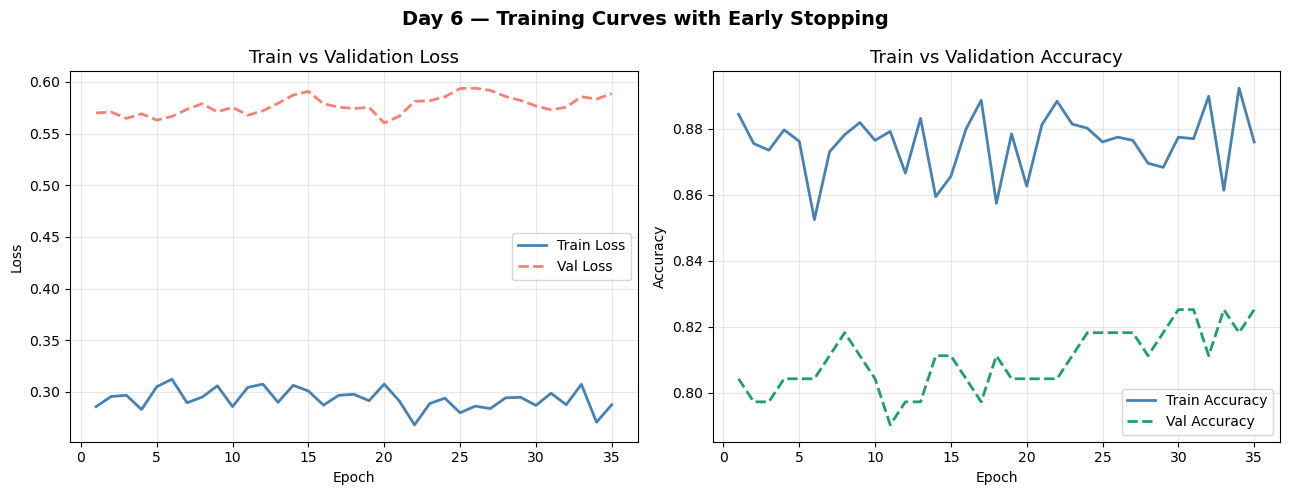

Curves saved ✓


In [56]:
os.makedirs('plots', exist_ok=True)
epochs_ran = range(1, len(train_losses) + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# Plot 1 — Loss curves
ax1.plot(epochs_ran, train_losses, label='Train Loss',
         color='steelblue', linewidth=2)
ax1.plot(epochs_ran, val_losses,   label='Val Loss',
         color='salmon',    linewidth=2, linestyle='--')
ax1.set_title('Train vs Validation Loss', fontsize=13)
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')
ax1.legend(); ax1.grid(True, alpha=0.3)

# Plot 2 — Accuracy curves
ax2.plot(epochs_ran, train_accs, label='Train Accuracy',
         color='steelblue', linewidth=2)
ax2.plot(epochs_ran, val_accs,   label='Val Accuracy',
         color='#1D9E75',   linewidth=2, linestyle='--')
ax2.set_title('Train vs Validation Accuracy', fontsize=13)
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy')
ax2.legend(); ax2.grid(True, alpha=0.3)

plt.suptitle('Day 6 — Training Curves with Early Stopping',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/day6_training_validation_curves.png', dpi=150)
plt.show()
print("Curves saved ✓")


In [60]:
# Final evaluation on unseen test set
model.eval()
with torch.no_grad():
    test_out  = model(x_test_t)
    test_pred = (test_out > 0.5).float()
    test_acc  = accuracy_score(y_test, test_pred.cpu().numpy())

print("="*40)
print(f"  Day 6 Final Test Accuracy: {test_acc:.4f} ({test_acc*100:.1f}%)")
print(f"  Day 5 Test Accuracy:       0.7989 (79.9%)")
print(f"  Improvement: {(test_acc - 0.7989)*100:+.1f}%")
print("="*40)

  Day 6 Final Test Accuracy: 0.7933 (79.3%)
  Day 5 Test Accuracy:       0.7989 (79.9%)
  Improvement: -0.6%


## Save Best Model Checkpoint
Saving model state dict, optimizer state and epoch number — a complete checkpoint for resuming training later.

In [61]:
os.makedirs('models', exist_ok=True)

# Save complete checkpoint
checkpoint = {
    'model_state_dict'    : model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'best_val_loss'       : best_val_loss,
    'test_accuracy'       : test_acc,
    'input_size'          : input_size
}
torch.save(checkpoint, 'models/day6_best_model.pth')
print("Checkpoint saved ✓")

# Verify reload
ckpt        = torch.load('models/day6_best_model.pth')
test_model  = TitanicNet(ckpt['input_size'])
test_model.load_state_dict(ckpt['model_state_dict'])
print(f"Reloaded — saved accuracy: {ckpt['test_accuracy']*100:.1f}%")
print("Checkpoint reload successful ✓")

Checkpoint saved ✓
Reloaded — saved accuracy: 79.3%
Checkpoint reload successful ✓


## Learning Rate Experiment
Testing 3 learning rates to find the optimal value — standard hyperparameter tuning practice.

In [64]:
lr_results = {}

for lr in [0.1, 0.01, 0.001]:
    m   = TitanicNet(input_size).to(device)
    opt = optim.Adam(m.parameters(), lr=lr)
    
    # Quick 50 epoch training
    for _ in range(50):
        m.train()
        for Xb, yb in train_loader:
            opt.zero_grad()
            loss = criteria(m(Xb), yb)
            loss.backward()
            opt.step()
    
    # Evaluate
    m.eval()
    with torch.no_grad():
        pred = (m(x_test_t) > 0.5).float()
        acc  = accuracy_score(y_test, pred.cpu().numpy())
    
    lr_results[lr] = acc
    print(f"LR: {lr:.3f} → Test Accuracy: {acc:.4f}")

best_lr = max(lr_results, key=lr_results.get)
print(f"\n🏆 Best learning rate: {best_lr}")

LR: 0.100 → Test Accuracy: 0.6536
LR: 0.010 → Test Accuracy: 0.8045
LR: 0.001 → Test Accuracy: 0.8156

🏆 Best learning rate: 0.001


In [65]:
# Open GitHub Desktop and commit with message:
# "Day 6: training loop, validation, early stopping, LR tuning"
print("Files to push:")
print("  day6_pytorch_training_loop.ipynb")
print("  plots/day6_training_validation_curves.png")
print("  models/day6_best_model.pth")
print("  README.md (after adding Day 6 section)")

Files to push:
  day6_pytorch_training_loop.ipynb
  plots/day6_training_validation_curves.png
  models/day6_best_model.pth
  README.md (after adding Day 6 section)
